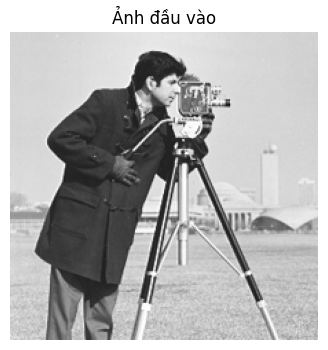

Kích thước tensor ảnh: torch.Size([1, 3, 224, 224])
Số patch: 196
Kích thước patches: torch.Size([1, 196, 3, 16, 16])


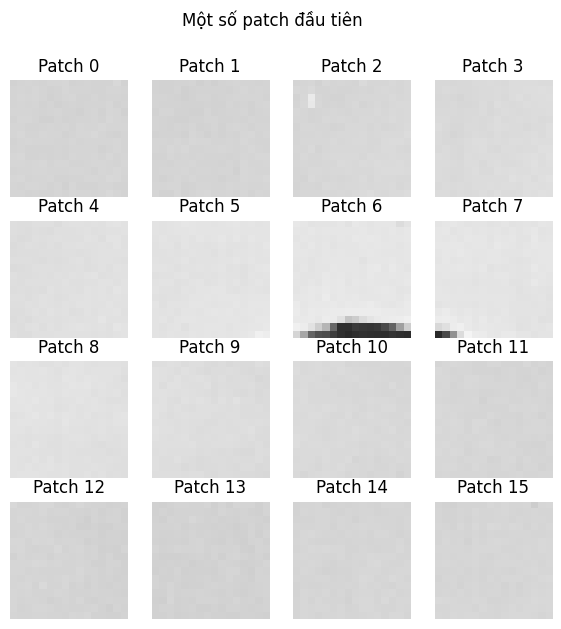

Kích thước patch vectors: torch.Size([1, 196, 768])
Kích thước tokens: torch.Size([1, 196, 64])
Kích thước X sau khi thêm [CLS] và vị trí: torch.Size([1, 197, 64])
Kích thước Q: torch.Size([1, 197, 64])
Kích thước K: torch.Size([1, 197, 64])
Kích thước V: torch.Size([1, 197, 64])
Kích thước attention weights: torch.Size([1, 197, 197])
Kích thước Z: torch.Size([1, 197, 64])


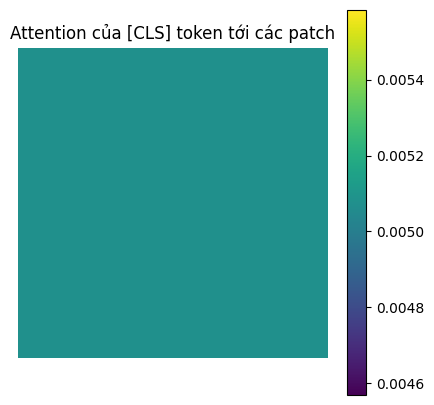

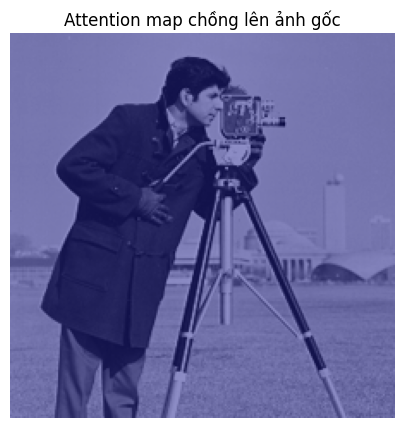

Tổng mỗi hàng của attention weights, 5 hàng đầu:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)
Sai số lớn nhất so với 1:
1.1920928955078125e-07
Kiểm tra thành công: self-attention tạo ra ma trận attention hợp lệ.


In [6]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: VISION TRANSFORMER - PATCH, TOKEN VÀ SELF-ATTENTION
# Chương/Mục liên quan: Chương 7 - Mô hình Transformer trong thị giác máy
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách Vision Transformer chia ảnh thành các patch và chuyển mỗi patch thành một token.
# - Giúp người học quan sát trực tiếp ma trận attention giữa các token trong cơ chế self-attention.
# - Liên hệ code với công thức Q = XW_Q, K = XW_K, V = XW_V và Attention(Q,K,V).

# Sau khi chạy code, người học cần:
# 1. Hiểu được ảnh được chia thành các patch như thế nào.
# 2. Hiểu được mỗi patch được biểu diễn thành một token vector ra sao.
# 3. Kiểm tra được attention weights là một phân phối xác suất theo từng hàng.

# Input:
# - Dữ liệu đầu vào: ảnh màu từ GitHub.
# - Kiểu dữ liệu: ảnh RGB, kích thước 224 x 224.
# - Tham số chính: patch_size, d_model, d_k.

# Output:
# - Ảnh đầu vào.
# - Một số patch được tách từ ảnh.
# - Kích thước các tensor trung gian: patch, token, Q, K, V, attention.
# - Attention map của [CLS] token tới các patch.
# - Kiểm tra tổng mỗi hàng của attention weights xấp xỉ bằng 1.

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

torch.manual_seed(0)

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

url = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img = img.resize((224, 224))

x = torch.tensor(np.array(img)).float() / 255.0
x = x.permute(2, 0, 1).unsqueeze(0)

B, C, H, W = x.shape

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Ảnh đầu vào")
plt.axis("off")
plt.show()

print("Kích thước tensor ảnh:", x.shape)

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# ------------------------------------------------------------
# 4.1. Chia ảnh thành các patch
# ------------------------------------------------------------

patch_size = 16

num_patches_h = H // patch_size
num_patches_w = W // patch_size
num_patches = num_patches_h * num_patches_w

patches = x.unfold(2, patch_size, patch_size)
patches = patches.unfold(3, patch_size, patch_size)
patches = patches.permute(0, 2, 3, 1, 4, 5)
patches = patches.reshape(B, num_patches, C, patch_size, patch_size)

print("Số patch:", num_patches)
print("Kích thước patches:", patches.shape)

# ------------------------------------------------------------
# 4.2. Hiển thị một số patch đầu tiên
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

for i in range(16):
    patch_img = patches[0, i].permute(1, 2, 0).numpy()

    plt.subplot(4, 4, i + 1)
    plt.imshow(patch_img)
    plt.title(f"Patch {i}")
    plt.axis("off")

plt.suptitle("Một số patch đầu tiên")
plt.show()

# ------------------------------------------------------------
# 4.3. Chuyển patch thành vector và token embedding
# ------------------------------------------------------------

patch_vectors = patches.reshape(B, num_patches, -1)

d_model = 64
patch_to_token = nn.Linear(C * patch_size * patch_size, d_model)

tokens = patch_to_token(patch_vectors)

print("Kích thước patch vectors:", patch_vectors.shape)
print("Kích thước tokens:", tokens.shape)

# ------------------------------------------------------------
# 4.4. Thêm [CLS] token và positional embedding
# ------------------------------------------------------------

cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))

cls_tokens = cls_token.expand(B, -1, -1)

X = torch.cat([cls_tokens, tokens], dim=1)
X = X + pos_embedding

print("Kích thước X sau khi thêm [CLS] và vị trí:", X.shape)

# ------------------------------------------------------------
# 4.5. Tính self-attention
# Công thức trong giáo trình:
# Q = XW_Q
# K = XW_K
# V = XW_V
# A = softmax(QK^T / sqrt(d_k))
# Z = AV
# ------------------------------------------------------------

d_k = 64

W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
attention_weights = torch.softmax(scores, dim=-1)
Z = torch.matmul(attention_weights, V)

print("Kích thước Q:", Q.shape)
print("Kích thước K:", K.shape)
print("Kích thước V:", V.shape)
print("Kích thước attention weights:", attention_weights.shape)
print("Kích thước Z:", Z.shape)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

cls_attention = attention_weights[0, 0, 1:]
cls_attention_map = cls_attention.reshape(num_patches_h, num_patches_w)

plt.figure(figsize=(5, 5))
plt.imshow(cls_attention_map.detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Attention của [CLS] token tới các patch")
plt.axis("off")
plt.show()

att = cls_attention_map.detach().numpy()
att = att / (att.max() + 1e-8)

attention_img = Image.fromarray((att * 255).astype(np.uint8))
attention_img = attention_img.resize((224, 224), resample=Image.BILINEAR)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.imshow(attention_img, cmap="jet", alpha=0.45)
plt.title("Attention map chồng lên ảnh gốc")
plt.axis("off")
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

row_sums = attention_weights[0].sum(dim=-1)
max_error = torch.max(torch.abs(row_sums - 1)).item()

print("Tổng mỗi hàng của attention weights, 5 hàng đầu:")
print(row_sums[:5])

print("Sai số lớn nhất so với 1:")
print(max_error)

assert patches.shape == (B, num_patches, C, patch_size, patch_size)
assert tokens.shape == (B, num_patches, d_model)
assert attention_weights.shape == (B, num_patches + 1, num_patches + 1)
assert max_error < 1e-5

print("Kiểm tra thành công: self-attention tạo ra ma trận attention hợp lệ.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay patch_size = 8 hoặc patch_size = 32 để quan sát số lượng patch thay đổi.
# 2. Thay d_model = 32 hoặc d_model = 128 để quan sát kích thước token embedding.
# 3. Thay alpha trong plt.imshow(attention_img, cmap="jet", alpha=0.45) để thay đổi độ trong suốt của attention map.